<a href="https://colab.research.google.com/github/TMDaniels75/HF-Data-Analytics-Program-/blob/main/Python%20Project%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [142]:
df=pd.read_csv("https://raw.githubusercontent.com/TMDaniels75/HF-Data-Analytics-Program-/refs/heads/main/NYPD_Arrest_Data_(Year_to_Date)_20260513.csv")

In [143]:
df

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69300,322107704,03/20/2026,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,71,0,25-44,M,WHITE HISPANIC,997877,181865,40.665852,-73.950879,POINT (-73.950879 40.665852)
69301,321792737,03/13/2026,244.0,"BURGLARY,UNCLASSIFIED,UNKNOWN",107.0,BURGLARY,PL 1402501,F,B,44,0,45-64,M,BLACK HISPANIC,1006537,244511,40.837782,-73.919457,POINT (-73.919457 40.837782)
69302,321311225,03/05/2026,259.0,"CRIMINAL MISCHIEF,UNCLASSIFIED 4",351.0,CRIMINAL MISCHIEF & RELATED OF,PL 1450001,M,M,26,0,25-44,M,WHITE HISPANIC,995270,235835,40.813992,-73.960190,POINT (-73.96019 40.813992)
69303,322521247,03/27/2026,764.0,BAIL JUMPING 1 & 2,126.0,MISCELLANEOUS PENAL LAW,PL 2155600,F,Q,102,0,45-64,M,BLACK,1032501,198800,40.712215,-73.825953,POINT (-73.825953 40.712215)


In [144]:
print(df.columns)

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')


In [145]:
borough_counts = df["ARREST_BORO"].value_counts()

In [146]:
print(borough_counts)

ARREST_BORO
K    21111
M    15870
B    15613
Q    14160
S     2551
Name: count, dtype: int64


In [147]:
borough_names = {
    "B": "Bronx",
    "K": "Brooklyn",
    "M": "Manhattan",
    "Q": "Queens",
    "S": "Staten Island"
}

borough_counts.index = borough_counts.index.map(borough_names)

In [148]:
print(borough_counts)

ARREST_BORO
Brooklyn         21111
Manhattan        15870
Bronx            15613
Queens           14160
Staten Island     2551
Name: count, dtype: int64


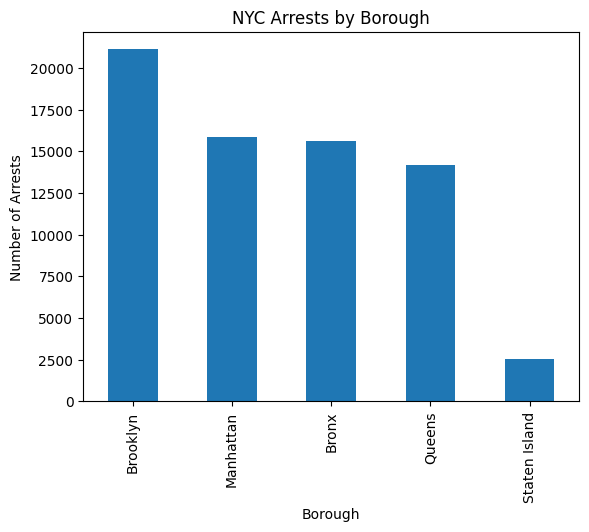

In [149]:
borough_counts.plot(kind="bar")

plt.title("NYC Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Arrests")

plt.show()

In [150]:
age_counts = df["AGE_GROUP"].value_counts()

In [151]:
print(age_counts)

AGE_GROUP
25-44     30798
(null)    16933
45-64     11386
18-24      7065
<18        1958
65         1165
Name: count, dtype: int64


<Axes: xlabel='AGE_GROUP'>

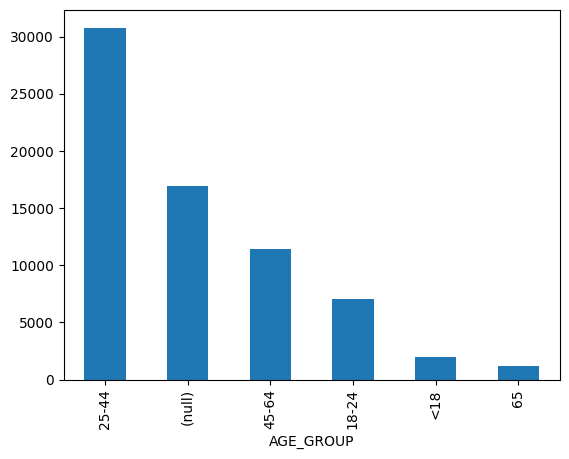

In [152]:
age_counts.plot(kind="bar")

In [153]:
df = df.dropna(subset=["AGE_GROUP"])

In [154]:
age_counts = df["AGE_GROUP"].value_counts()

In [155]:
desired_order = ["<18", "18-24", "25-44", "45-64", "65+"]

In [156]:
age_counts = age_counts.reindex(desired_order)


In [157]:
print(age_counts)

AGE_GROUP
<18       1958.0
18-24     7065.0
25-44    30798.0
45-64    11386.0
65+          NaN
Name: count, dtype: float64


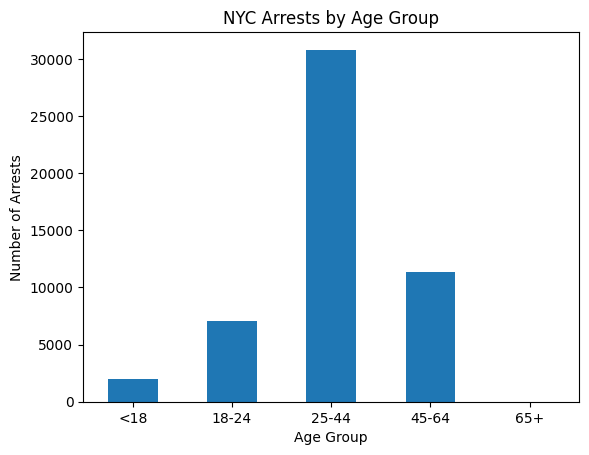

In [158]:
age_counts.plot(kind="bar")
plt.title("NYC Arrests by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=0)
plt.show()

In [159]:
df = df.dropna(subset=["OFNS_DESC"])

In [160]:
df = df[df["OFNS_DESC"] != "NULL"]

In [161]:
crime_counts = df["OFNS_DESC"].value_counts()

In [162]:
top_crimes = crime_counts.head(10)

In [163]:
print(top_crimes)

OFNS_DESC
ASSAULT 3 & RELATED OFFENSES       9415
PETIT LARCENY                      6478
DANGEROUS DRUGS                    5726
FELONY ASSAULT                     5462
VEHICLE AND TRAFFIC LAWS           4776
MISCELLANEOUS PENAL LAW            4627
OTHER OFFENSES RELATED TO THEFT    4019
CRIMINAL MISCHIEF & RELATED OF     2929
OFFENSES AGAINST PUBLIC ADMINI     2679
ROBBERY                            2593
Name: count, dtype: int64


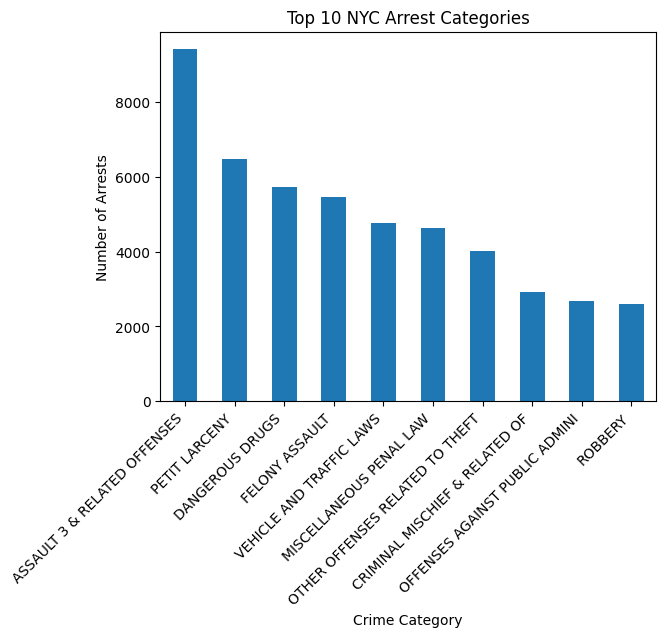

In [164]:
top_crimes.plot(kind="bar")
plt.title("Top 10 NYC Arrest Categories")
plt.xlabel("Crime Category")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=45, ha="right")
plt.show()

In [198]:
gender_counts = df["PERP_SEX"].value_counts()
gender_counts = gender_counts.rename(index={'M': 'Male', 'F': 'Female'})
print(gender_counts)

PERP_SEX
Male      42719
Female     9653
Name: count, dtype: int64


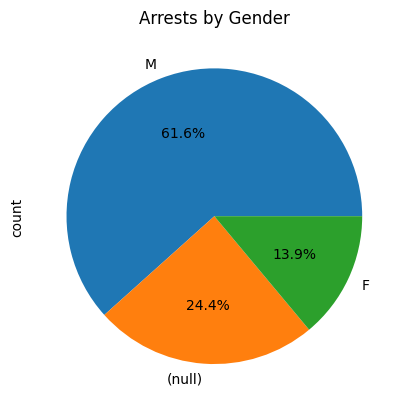

In [168]:
gender_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Arrests by Gender")

plt.show()


In [197]:
df["PERP_SEX"] = df["PERP_SEX"].replace("(null)", np.nan)


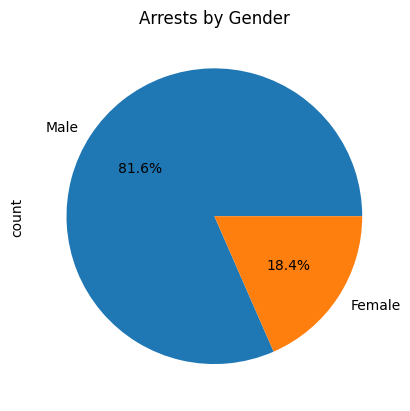

In [199]:
gender_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Arrests by Gender")

plt.show()